# Semester Project: Fake News Detection Using Logistic Regression
### Import Libraries:

In [111]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from scipy.sparse import hstack


### Load Dataset:

In [112]:
# Loading datasets
fake = pd.read_csv("Fake.csv")
real = pd.read_csv("True.csv")

# Adding labels
fake["label"] = 0   
real["label"] = 1   

# Combining datasets
data = pd.concat([fake, real], axis=0)

# Shuffling data
data = data.sample(frac=1, random_state=42).reset_index(drop=True)
data.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


### Mark Required columns:

In [113]:
# Required columns
data = data[["title", "text", "subject", "date", "label"]]
print("Dataset shape:", data.shape)

Dataset shape: (44898, 5)


### Data Pre-processing:

In [ ]:
# encoding

def handle_outliers_IQR(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df[column] = np.where(df[column] < lower, lower,
                     np.where(df[column] > upper, upper, df[column]))


def encode_labels(df, columns):
    encoders = {}
    for c in columns:
        le = LabelEncoder()
        df[c] = le.fit_transform(df[c].astype(str))
        encoders[c] = le
    return df, encoders


### Dataset Size Adjustment:

In [115]:
# Reducing dataset size for better performance (>= 900 rows)
data = data.sample(n=3000, random_state=42).reset_index(drop=True)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

# Handling missing values
data["clean_text"] = (
    data["title"].fillna("") + " " + data["text"].fillna("")
)

# Applying text cleaning
data["clean_text"] = data["clean_text"].apply(clean_text)
data = data.drop_duplicates().reset_index(drop=True)

# Previewing cleaned data
data.head()

,title,text,subject,date,label,clean_text
0,It’s Really Happening: Trump Adviser Lays Out...,"Well, that didn t take long. In the short time...",News,"November 16, 2016",0,its really happening trump adviser lays out p...
1,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",1,republican attempt to deflect trumprussia prob...
2,Trump says churches should get FEMA funds for ...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"September 9, 2017",1,trump says churches should get fema funds for ...
3,Trump Loves To Say The New York Times Is ‘Fai...,Print journalism and longstanding papers have ...,News,"August 7, 2017",0,trump loves to say the new york times is fail...
4,House Speaker Ryan briefed Trump on healthcare...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"March 24, 2017",1,house speaker ryan briefed trump on healthcare...


### Feature Engineering:

In [116]:
# 1: Word count
data["word_count"] = data["clean_text"].apply(lambda x: len(x.split()))

# 2: Character count
data["char_count"] = data["clean_text"].apply(len)

# 3: Average word length
data["avg_word_len"] = data["char_count"] / data["word_count"]

# 4: Title length
data["title_len"] = data["title"].apply(len)

# 5: Uppercase words count
data["upper_words"] = data["text"].apply(lambda x: sum(1 for w in str(x).split() if w.isupper()))

# Encoding subject
data["subject_encoded"] = data["subject"].factorize()[0]

data.head()

,title,text,subject,date,label,clean_text,word_count,char_count,avg_word_len,title_len,upper_words,subject_encoded
0,It’s Really Happening: Trump Adviser Lays Out...,"Well, that didn t take long. In the short time...",News,"November 16, 2016",0,its really happening trump adviser lays out p...,533,3263,6.121951,80,1,0
1,Republican attempt to deflect Trump-Russia pro...,(Reuters) - Republican lawmaker Devin Nunes’ i...,politicsNews,"September 11, 2017",1,republican attempt to deflect trumprussia prob...,553,3663,6.623870,73,8,1
2,Trump says churches should get FEMA funds for ...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"September 9, 2017",1,trump says churches should get fema funds for ...,326,2020,6.196319,62,8,1
3,Trump Loves To Say The New York Times Is ‘Fai...,Print journalism and longstanding papers have ...,News,"August 7, 2017",0,trump loves to say the new york times is fail...,315,1897,6.022222,115,5,0
4,House Speaker Ryan briefed Trump on healthcare...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"March 24, 2017",1,house speaker ryan briefed trump on healthcare...,127,730,5.748031,71,4,1


### Handling Outliers:

In [117]:
# Outlier handling

num_cols = ["word_count", "char_count", "avg_word_len", "title_len", "upper_words"]

for col in num_cols:
    if col in data.columns:
        handle_outliers_IQR(data, col)

print("Outliers handled ")


Outliers handled 


### Scaling Numerical Features:

In [ ]:
# Scaling numerical features 
scaler = StandardScaler()
scaled_cols = [col + "_scaled" for col in num_cols]

data[scaled_cols] = scaler.fit_transform(data[num_cols])

print("Numerical features scaled")
print(data[scaled_cols].head())

Numerical features scaled
   word_count_scaled  char_count_scaled  avg_word_len_scaled  \
0           0.558144           0.612526             0.325053   
1           0.639267           0.885088             1.883886   
2          -0.281476          -0.234463             0.556020   
3          -0.326093          -0.318276             0.015319   
4          -1.088646          -1.113477            -0.836249   

   title_len_scaled  upper_words_scaled  
0          0.037901           -0.968507  
1         -0.281405            0.189618  
2         -0.783171            0.189618  
3          1.634431           -0.306721  
4         -0.372635           -0.472168  


### Applying TF-IDF: Feature Extraction

In [119]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=3000
)

X_tfidf = tfidf.fit_transform(data["clean_text"])

# Extra numerical features
X_numeric = data[
    ["word_count", "char_count", "avg_word_len",
     "title_len", "upper_words", "subject_encoded"]
]

# Combining TF-IDF + numerical features
from scipy.sparse import hstack
X = hstack([X_tfidf, X_numeric])

y = data["label"]

### Final cleaned dataset:

In [121]:
# Final clean dataset
final_clean_df = pd.concat(
    [data[["label"]], data[scaled_cols + ["subject_encoded"]]],
    axis=1
)

print(final_clean_df.head())
print("Final Cleaned Dataframe Shape:", final_clean_df.shape)

   label  word_count_scaled  char_count_scaled  avg_word_len_scaled  \
0      0           0.558144           0.612526             0.325053   
1      1           0.639267           0.885088             1.883886   
2      1          -0.281476          -0.234463             0.556020   
3      0          -0.326093          -0.318276             0.015319   
4      1          -1.088646          -1.113477            -0.836249   

   title_len_scaled  upper_words_scaled  subject_encoded  
0          0.037901           -0.968507                0  
1         -0.281405            0.189618                1  
2         -0.783171            0.189618                1  
3          1.634431           -0.306721                0  
4         -0.372635           -0.472168                1  
Final Cleaned Dataframe Shape: (2998, 7)


### Splitting sample dataset:

In [122]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 2398
Testing samples: 600


### Using Logistic Regression:

In [123]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Logistic Regression with liblinear solver:

In [124]:
model = LogisticRegression(
    max_iter=3000,
    solver="liblinear"
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,3000
,multi_class,'deprecated'


### Classification report of model:

In [125]:
y_pred = model.predict(X_test)

# Accuracy of model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification report on model
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9633333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       295
           1       0.96      0.97      0.96       305

    accuracy                           0.96       600
   macro avg       0.96      0.96      0.96       600
weighted avg       0.96      0.96      0.96       600



### Confusion Matrix Heatmap:

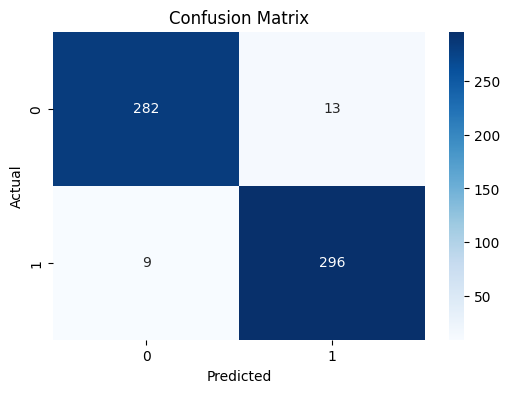

In [126]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Top words for classification:

In [127]:
# Top words influencing predictions
feature_names = tfidf.get_feature_names_out()

coefficients = model.coef_[0][:len(feature_names)]

top_fake = np.argsort(coefficients)[:10]
top_real = np.argsort(coefficients)[-10:]

print("Top words that indicates FAKE news:")
print(feature_names[top_fake])

print("\nTop words that indicates REAL news:")
print(feature_names[top_real])

Top words that indicates FAKE news:
['video' 'hillary' 'image' 'wire' 'just' 'trump' 'obama' 'like' 'america'
 'st']

Top words that indicates REAL news:
['korea' 'tax' 'north' 'wednesday' 'friday' 'washington' 'minister'
 'trumps' 'reuters' 'said']


### Horizontal bar distribution for Top words for classification

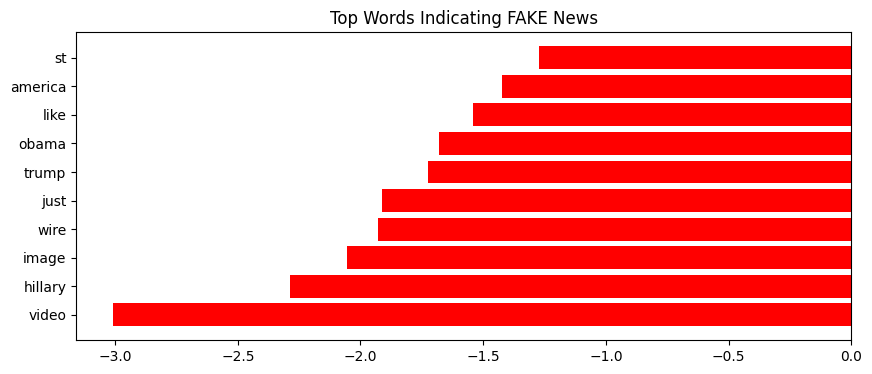

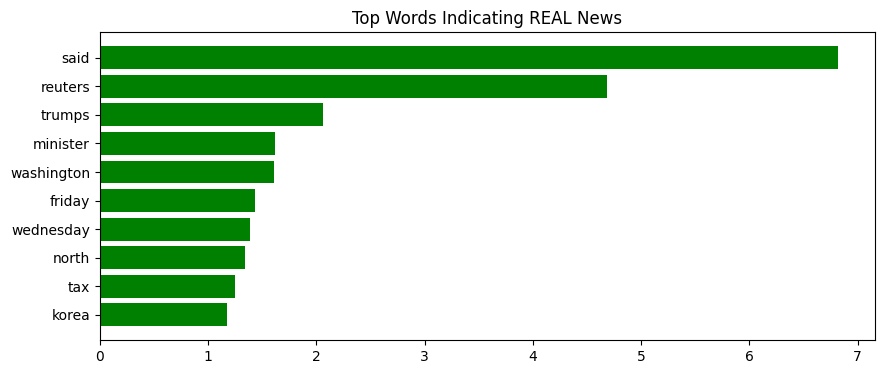

In [128]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0][:len(feature_names)]

# For Fake News
top_fake = np.argsort(coefficients)[:10]
# For Real News
top_real = np.argsort(coefficients)[-10:]

plt.figure(figsize=(10,4))
plt.barh(feature_names[top_fake], coefficients[top_fake], color='red')
plt.title("Top Words Indicating FAKE News")
plt.show()

plt.figure(figsize=(10,4))
plt.barh(feature_names[top_real], coefficients[top_real], color='green')
plt.title("Top Words Indicating REAL News")
plt.show()

### Sparse to dense TF-IDF conversion for ANN:

In [134]:
# Converting sparse TF-IDF to dense for ANN training
# Combine TF-IDF + All numeric features 
X_numeric_full = data[scaled_cols + ["subject_encoded"]]

X = hstack([X_tfidf, X_numeric_full])

X_train_dense = X_train.toarray()
X_test_dense = X_test.toarray()

print("Dense shapes:", X_train_dense.shape, X_test_dense.shape)


Dense shapes: (2398, 3006) (600, 3006)


### Combining Sparse and dense TF-IDF matrix

In [135]:
# Selecting scaled numerical features + encoded categorical
X_numeric = data[
    [
        "word_count_scaled",
        "char_count_scaled",
        "avg_word_len_scaled",
        "title_len_scaled",
        "upper_words_scaled",
        "subject_encoded"
    ]
]

# Combining sparse TF-IDF + dense numerical matrix
X = hstack([X_tfidf, X_numeric])

# Labeling
y = data["label"]

print("Final Prepared Dataset: ")
print("TF-IDF:", X_tfidf.shape)
print("Numeric:", X_numeric.shape)
print("Final X:", X.shape)

Final Prepared Dataset: 
TF-IDF: (2998, 3000)
Numeric: (2998, 6)
Final X: (2998, 3006)


### Using ANN:

In [130]:
# ANN Training:
input_dim = X_train_dense.shape[1]

# ANN Model
ann_model = Sequential([
    Dense(256, activation='relu', input_shape=(input_dim,)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# To prevent overfitting
early_stop = EarlyStopping(
    monitor='val_accuracy', 
    patience=3, 
    restore_best_weights=True
)

# Train model
history = ann_model.fit(
    X_train_dense, y_train,
    validation_data=(X_test_dense, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

C:\Users\lenovo\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8757 - loss: 0.3388 - val_accuracy: 0.9767 - val_loss: 0.0764
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9846 - loss: 0.0476 - val_accuracy: 0.9800 - val_loss: 0.0445
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9971 - loss: 0.0138 - val_accuracy: 0.9917 - val_loss: 0.0341
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9996 - loss: 0.0044 - val_accuracy: 0.9867 - val_loss: 0.0322
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9996 - loss: 0.0016 - val_accuracy: 0.9900 - val_loss: 0.0372
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 1.0000 - loss: 6.0871e-04 - val_accuracy: 0.9883 - val_loss: 0.0327


### ANN Classification Report:

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ANN Test Accuracy: 0.9916666666666667

ANN Confusion Matrix:
[[295   0]
 [  5 300]]

ANN Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       295
           1       1.00      0.98      0.99       305

    accuracy                           0.99       600
   macro avg       0.99      0.99      0.99       600
weighted avg       0.99      0.99      0.99       600



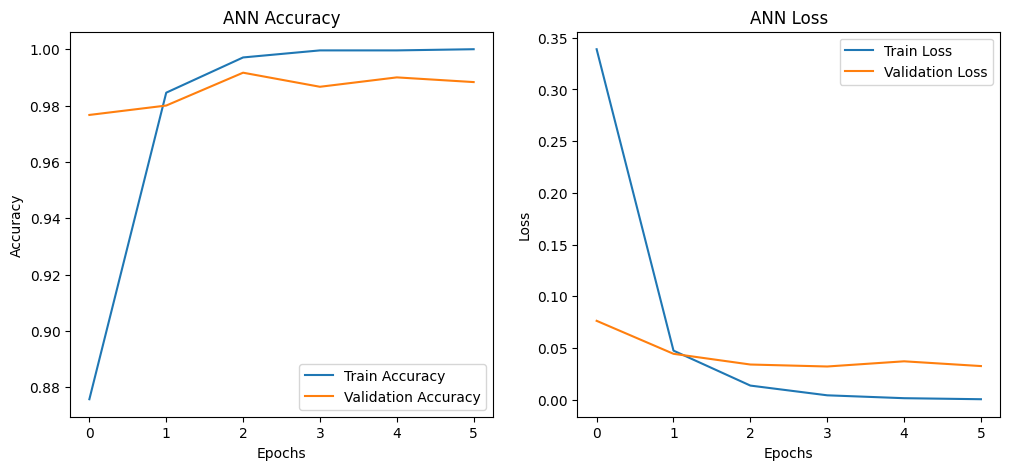

In [131]:
# ANN Evaluation
ann_probs = ann_model.predict(X_test_dense).ravel()
ann_preds = (ann_probs >= 0.5).astype(int)

# Test Accuracy
print("ANN Test Accuracy:", accuracy_score(y_test, ann_preds))

# Confusion Matrix
print("\nANN Confusion Matrix:")
print(confusion_matrix(y_test, ann_preds))

# Classification Report
print("\nANN Classification Report:")
print(classification_report(y_test, ann_preds))

# Optional: plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


### ANN Confusion Matrix Heatmap:

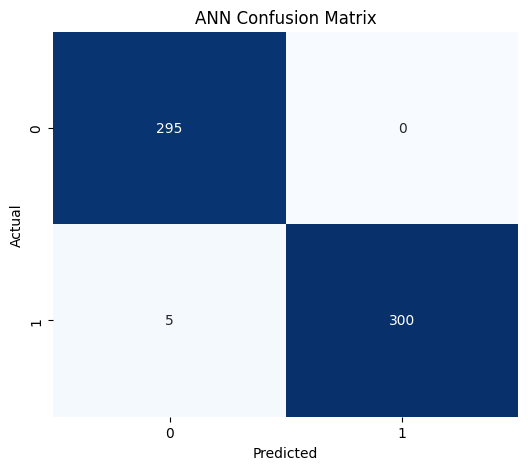

In [132]:
# confusion matrix
cm = confusion_matrix(y_test, ann_preds)

# Plotting heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


### Comparing Models:

In [ ]:
# Model Comparison Report

# Logistic Regression Results
log_acc = accuracy_score(y_test, y_pred) 

# ANN Results 
ann_acc = accuracy_score(y_test, ann_preds)

print("Model Comparison: ")
print(f"Logistic Regression (SGD) Accuracy: {log_acc:.4f}")
print(f"ANN Accuracy: {ann_acc:.4f}")

# Creating comparison dataframe
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression (SGD)", "Artificial Neural Network (ANN)"],
    "Accuracy": [log_acc, ann_acc]
})

print("\nComparison Table:")
display(comparison_df)

Model Comparison: 
Logistic Regression (SGD) Accuracy: 0.9633
ANN Accuracy: 0.9917

Comparison Table:


,Model,Accuracy
0,Logistic Regression (SGD),0.963333
1,Artificial Neural Network (ANN),0.991667
